In [53]:
#from a fieldmap in straight coordinates to one in curved coordinates
import numpy as np
import matplotlib.pyplot as plt
from math import factorial
import bpmeth
from sympy import lambdify 
from sympy.abc import x, y, s
import pyvista as pv
from numpy.polynomial.chebyshev import chebvander
from numpy.polynomial.chebyshev import Chebyshev
from numpy.polynomial.polynomial import Polynomial
from scipy.interpolate import CubicSpline

(0.0, 1.0)

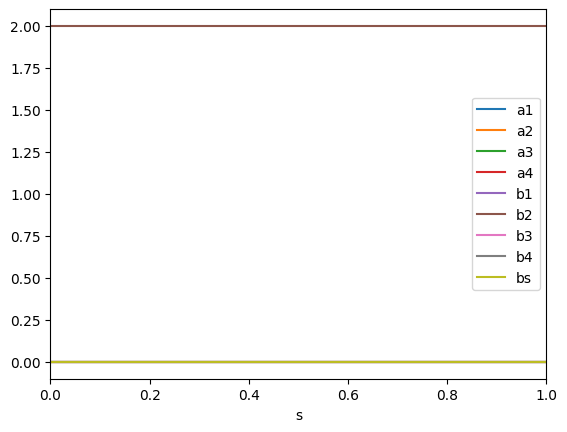

In [117]:
#start from multipole coeefficients a_n(s)=a1,a2,... and b_n(s)
a_coeffs = [0, 0, 0, 0]
b_coeffs = [0.,2.,0, 0]
#get scalar potential
expansion=bpmeth.FieldExpansion(a=a_coeffs, b=b_coeffs)
expansion.plot_components()
plt.xlabel('s')
plt.xlim((0,1))

Scalar potential phi(x,y,s): 2.0*x*y
Scalar potential phi at (0.4,0.2,0.5): 0.16000000000000003


/home/fmarcoli/bpmeth/src/bpmeth/generate_expansion.py:96: UserWarning: The laplacian could not be evaluated
  warnings.warn("The laplacian could not be evaluated")


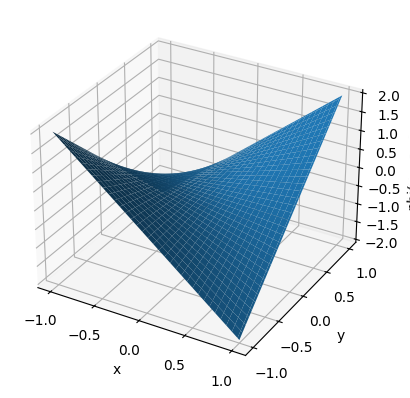

In [118]:
phi=expansion.get_phi()
print("Scalar potential phi(x,y,s):", phi)

XYS=(x,y,s)#symbolic expressions

phi_func = lambdify(XYS, phi, 'numpy')#from symbolic to numerical function
print("Scalar potential phi at (0.4,0.2,0.5):", phi_func(0.4,0.2,0.5))
#define x,y,s axes to convert the symbolic expression of phi into a numerical array
xa= np.linspace(-1,1,101)
ya=np.linspace(-1,1,101)
sa=np.linspace(-1,1,101)
#make a 3d plot of phi as a function of x and y for a fixed s
X, Y = np.meshgrid(xa, ya)
P = phi_func(X, Y, 0.5)#s=0.5 is the middle  of the magnet
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, P)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('phi(x,y,s=0.5)')
plt.show()

In [119]:
# Get analytical B field functions
Bx_func, By_func, Bs_func = expansion.get_Bfield(lambdify=True)
#print("Bx:", Bx_func, "By:", By_func, "Bs:", Bs_func)
# Evaluate on grid
X,Y,S = np.meshgrid(xa, ya, sa)
Bx_ana = Bx_func(X, Y, S)
By_ana = By_func(X, Y, S)
Bs_ana = Bs_func(X, Y, S)
#print("Bx shape:", Bx_ana.shape, "By shape:", By_ana.shape, "Bs shape:", Bs_ana.shape)
# X, Y, S  from meshgrid in straight frame
# Bx_ana, By_ana, Bs_ana are the corresponding field arrays
datafieldmap = np.column_stack([
    X.ravel(),
    Y.ravel(),
    S.ravel(),
    Bx_ana.ravel(),
    By_ana.ravel(),
    Bs_ana.ravel()
])
#print("Data shape (N, 6):", datafieldmap.shape)
fm = bpmeth.fieldmaps.Fieldmap(datafieldmap)
#print(xa.shape)

Pass to FS coordinates

In [120]:
rho = .5
phi = 1.
xFS = np.linspace(-0.05, 0.05, 101)
yFS = np.linspace(-0.05, 0.05, 101)
sFS = np.linspace(-rho*phi, rho*phi, 103)
interp_rad=0.025
fm_fs = fm.calc_FS_coords(xFS, yFS, sFS, rho, phi, radius=interp_rad)
#print(fm_fs.get_data()[:,0])

Now I can extract multipole coefficients using harmonic analysis

In [121]:
# Choose a fixed s value (s=0 is the magnet center)
s_fixed = 0.0

bnianHA=fm_fs.harmonic_analysis_at_s(spos=s_fixed,rmin=0.01,rmax=1.0 )
bnHA=bnianHA.real
print("recovered bn(0) in curved frame: ", bnHA)

recovered bn(0) in curved frame:  [1.12677750e+00 2.17358436e+00 1.51211902e+02 6.49694775e+03
 2.94391922e+03]


HA along s

In [122]:
#svals, bnofs, errorbn = fm_fs.s_harmonics(order=4, rmin=0.001, rmax= 0.05, nr=40, radius=interp_rad)

In [123]:
def fieldmap_to_cylindrical(
    fieldmap,
    rmin=0.001,
    rmax=0.101,
    nr=128,
    ntheta=128,
    smin=-1.0,
    smax=1.0,
    ns=401,
    radius=0.02,
    theta_endpoint=False,
    field_names=("Bx", "By", "Bs"),
):
    """
    Resample a Frenet-Serret fieldmap onto a straight cylindrical grid.

    The fieldmap columns are [x, y, s, Bx, By, Bs] where x and y are
    transverse Cartesian offsets from the reference orbit and s is the
    arc length. This is equivalent to a straight Cartesian frame, so
    x → x, y → y, s → z.

    The output cylindrical grid uses:
        x = r * cos(theta)
        y = r * sin(theta)
        z = s

    Parameters
    ----------
    fieldmap : ndarray, shape (N, 6)
        Columns: [x, y, s, F1, F2, F3].
    rmin, rmax : float
        Radial range [m].
    nr, ntheta, ns : int
        Grid resolution.
    smin, smax : float
        Arc-length range [m].
    radius : float
        Interpolation radius [m].
    theta_endpoint : bool
        Whether theta includes 2*pi.
    field_names : tuple[str]
        Names for the 3 field columns.

    Returns
    -------
    r_1d, theta_1d, s_1d : 1D coordinate arrays
    R, TH, S : 3D meshgrid arrays, shape (nr, ntheta, ns)
    fields : dict[str, ndarray], each shape (nr, ntheta, ns)
    dst : pyvista.StructuredGrid
    """
    fieldmap = np.asarray(fieldmap)
    if fieldmap.ndim != 2 or fieldmap.shape[1] < 6:
        raise ValueError("fieldmap must have shape (N, 6) or more")

    # ---------------------------------
    # 1. Source: x, y, s → straight Cartesian
    # ---------------------------------
    src = pv.PolyData(fieldmap[:, :3])   # columns are already (x, y, s)
    for i, name in enumerate(field_names):
        src.point_data[name] = fieldmap[:, 3 + i]

    # ---------------------------------
    # 2. Target: straight cylindrical grid
    # ---------------------------------
    r_1d = np.linspace(rmin, rmax, nr)
    theta_1d = np.linspace(0.0, 2.0*np.pi, ntheta, endpoint=theta_endpoint)
    s_1d = np.linspace(smin, smax, ns)

    R, TH, S = np.meshgrid(r_1d, theta_1d, s_1d, indexing="ij")

    X = R * np.cos(TH)
    Y = R * np.sin(TH)
    Z = S                 # s is the third axis, maps directly to z

    dst = pv.StructuredGrid(X, Y, Z) #destination grid

    # ---------------------------------
    # 3. Bounds check
    # ---------------------------------
    print("Source bounds:", src.bounds)
    print("Target bounds:", dst.bounds)

    # ---------------------------------
    # 4. Interpolate
    # ---------------------------------
    dst = dst.interpolate(src, radius=radius, sharpness=2.0, strategy="null_value",null_value=np.nan)

    for name in field_names: #check how many succsessful interpolations we got
        frac = np.isfinite(dst.point_data[name]).sum() / dst.n_points 
        print(f"{name} finite fraction = {frac:.4f}")

    # ---------------------------------
    # 5. Reshape onto cylindrical grid
    # ---------------------------------
    fields = {}
    for name in field_names:
        arr = np.asarray(dst.point_data[name])
        fields[name] = arr.reshape(R.shape, order="F")

    return r_1d, theta_1d, s_1d, R, TH, S, fields, dst

In [ ]:
rmin=xFS[len(xFS)//2+1]
rmax=xFS[-1]
print("r min",rmin,"r max", rmax)
#thetahalf = phi/2
smax=sFS.max()
#smax=rho*thetahalf#to get only curved part
print(f"smax: {smax:.3f} m")
#print("thetahalf (degrees):", np.degrees(thetahalf))
datafs=fm_fs.get_data()
#print(datafs.shape,"\n", datafs[0:5])
nr=64
ntheta=128
r_1d, theta_1d, s_1d, R, TH, S, fields, dst = fieldmap_to_cylindrical(
    datafs,
    rmin=rmin,
    rmax=rmax,
    nr=nr,
    ntheta=ntheta,
    smin=-smax,
    smax=smax,
    ns=len(sFS),
    radius=interp_rad, 
    field_names=("Bx", "By", "Bs"),)

#print("r_1d:", r_1d[0:5])
#print(fields['By'][0:5])
ByiBx_rts = fields["By"] + 1j*fields["Bx"]#shape (nr, ntheta, ns)
print(ByiBx_rts[0:5])

r min 0.0010000000000000009 r max 0.05
smax: 0.500 m
Source bounds: BoundsTuple(x_min = -0.05,
            x_max =  0.05,
            y_min = -0.05,
            y_max =  0.05,
            z_min = -0.5,
            z_max =  0.5)
Target bounds: BoundsTuple(x_min = -0.05,
            x_max =  0.05,
            y_min = -0.05,
            y_max =  0.05,
            z_min = -0.5,
            z_max =  0.5)
Bx finite fraction = 1.0000
By finite fraction = 1.0000
Bs finite fraction = 1.0000
[[[0.63979725+0.00000000e+00j 0.6470121 +0.00000000e+00j
   0.65799202+1.90295384e-19j ... 0.65799202+1.90295384e-19j
   0.6470121 +0.00000000e+00j 0.63979725+0.00000000e+00j]
  [0.64352438+9.19138819e-05j 0.64956668+9.19600406e-05j
   0.65835493+9.15924156e-05j ... 0.65835493+9.15924156e-05j
   0.64956668+9.19600406e-05j 0.64352438+9.19138819e-05j]
  [0.64351925+1.78896492e-04j 0.64956072+1.78733909e-04j
   0.6583479 +1.78133361e-04j ... 0.6583479 +1.78133361e-04j
   0.64956072+1.78733909e-04j 0.64351925+1.

In [134]:
print("ByiBx_rts shape:", ByiBx_rts.shape)
datacylindricalFS=fm.calc_FS_coords_cylindrical(rFS=np.linspace(rmin, rmax, nr), thetaFS=np.linspace(0, np.pi*2, ntheta), sFS=sFS, rho=rho, phi=phi,radius=interp_rad)
reshapeddata=datacylindricalFS.get_data().reshape((nr, ntheta, len(sFS),6))#, order="F")
cilByiBx=reshapeddata[:,:,:,4]+1j*reshapeddata[:,:,:,3] #check
print(cilByiBx[0:5])
print("cilByiBx shape:", cilByiBx.shape)

ByiBx_rts shape: (64, 128, 103)
[[[0.63979725+0.00000000e+00j 0.63979609+4.69062924e-05j
   0.63979262+9.37020424e-05j ... 0.63906892-9.25243952e-04j
   0.63911458-9.13324363e-04j 0.63915953-8.99118730e-04j]
  [0.63920366-8.82665147e-04j 0.63924688-8.64008013e-04j
   0.63928907-8.43197799e-04j ... 0.64429585-5.61644042e-04j
   0.6443249 -6.04168652e-04j 0.64435619-6.45155971e-04j]
  [0.64500681-6.94016488e-04j 0.64503885-7.32071498e-04j
   0.64507281-7.68248282e-04j ... 0.65415064+6.53099332e-04j
   0.65408975+6.11254938e-04j 0.65403306+5.67927855e-04j]
  ...
  [0.83985186-1.94877186e-03j 0.83994865-2.10447645e-03j
   0.84005196-2.25619656e-03j ... 0.84816113+2.97836373e-03j
   0.8475596 +2.87840775e-03j 0.84675772+2.69671066e-03j]
  [0.84658884+2.54876399e-03j 0.84643075+2.39739652e-03j
   0.84628352+2.24308124e-03j ... 0.86808687+3.96545130e-03j
   0.86781306+4.04537516e-03j 0.867352  +4.67391551e-03j]
  [0.86664876+5.18010477e-03j 0.86633306+5.23708538e-03j
   0.86600912+5.28557674e

In [126]:
#with new HA method:
def dkongrid(Byibx_rts, rr, nk, s_index):
    """
    Takes a precomputed field array and computes d_k as a function of r 
    Parameters
    ----------
    Byibx_rts : complex array, shape (nr, ntheta, ns) representing (By + i*Bx) already evaluated on the (r, theta, s) grid.
    Theta samples must be uniform in [0, 2*pi).
    rr     : array of r values, shape (nr,)
    nk     : max |k|
    s_index: index along the s-axis to use
    
    Returns
    -------
    out : complex array, shape (nr, 2*nk+1)  — same as dkharmonics
    """
    ntheta = Byibx_rts.shape[1]

    b = Byibx_rts[:, :, s_index]        # (nr, ntheta) at specified s
    d = np.fft.fft(b, axis=1) / ntheta       # FFT along theta axis

    out = np.empty((len(rr), 2*nk+1), dtype=complex)
    out[:, 0]    = d[:, 0]
    out[:, 1::2] = d[:, 1 : nk+1]
    out[:, 2::2] = d[:, ntheta : ntheta-nk-1 : -1]

    return out

def dklfitraw_nodiv_cheb(dkofrarray, rr, nk, nl):                                                                                        #Cg
    """
    Numerically stable Chebyshev version of dklfitraw_nodiv.
    Fits     f_k(r) ≈ Σ_l dkl[k,l] r^{|k|+2l}
    exactly like dklfitraw_nodiv, but internally uses a
    Chebyshev basis in x = r^2 for improved conditioning.
    Returns
    -------
    dkl : complex ndarray, shape (2*nk+1, nl)
        Coefficients with exactly the same meaning as dklfitraw_nodiv:  f_k(r) ≈ Σ_l dkl[k,l] r^{|k|+2l}
    """
    dkl = np.zeros((2*nk + 1, nl), dtype=complex)
    x = rr**2
    xmin = x.min()
    xmax = x.max()
    s = 2*(x - xmin)/(xmax - xmin) - 1 # scale x -> s in [-1,1]
    # Chebyshev Vandermonde in scaled variable
    T = chebvander(s, nl-1)
    # k ordering:
    # [0, +1, -1, +2, -2, ...]
    for ik in range(2*nk + 1):
        if ik == 0:
            kabs = 0
        else:
            kabs = (ik + 1)//2
        # absorb r^|k| into the matrix itself
        A = (rr[:, None]**kabs) * T
        y = dkofrarray[:, ik]
        # stable least squares in Chebyshev basis
        c_re, _, _, _ = np.linalg.lstsq(A, y.real, rcond=None)
        c_im, _, _, _ = np.linalg.lstsq(A, y.imag, rcond=None)
        c = c_re + 1j*c_im
        # Convert:  Σ c_n T_n(s)    into ordinary polynomial in x=r^2: Σ a_l x^l
        cheb = Chebyshev(c, domain=[xmin, xmax])
        poly = cheb.convert(kind=Polynomial)
        coeffs = poly.coef
        # store coefficients of x^l so total basis is    r^|k| * (r^2)^l = r^{|k|+2l}
        ncopy = min(len(coeffs), nl)
        dkl[ik, :ncopy] = coeffs[:ncopy]
    return dkl
#now let's recover the a,b coefficients
def bnianHAopt(dkl, nl, nk):#from dkl to bn and an
    # Precompute factorials
    fact = np.array([factorial(n) for n in range(nk)], dtype=np.int16)

    # Build k index dict mapping: row index for k = 0,1,-1,2,-2,...
    k_index = {0: 0}
    for i in range(1, nk+1):
        k_index[i]  = 2*i - 1
        k_index[-i] = 2*i #negative k gets even row

    result = np.zeros(nk, dtype=np.complex128)

    for n in range(nk):
        s = 0.0 + 0.0j #initialize sum
        max_l = min(n//2, nl-1)

        for l in range(max_l + 1):#
            k = n - 2*l
            if k == 0:
                s += dkl[k_index[0], l]
            else:
                s += dkl[k_index[k], l] + dkl[k_index[-k], l]

        result[n] = fact[n] * s

    return result
def LHongrid_nodiv_cheb(ByiBxongrid, s_index, nk):
    '''
    local harmonic analysis from By+iBx to dkl and coefficients a,b 
    '''
    dk=dkongrid(Byibx_rts=ByiBxongrid, rr=rr, nk=nk, s_index=s_index)
    dkl=dklfitraw_nodiv_cheb(dkofrarray=dk,rr=rr,nk=nk, nl=nl)
    an=bnianHAopt(dkl, nl,nk).imag
    bn=bnianHAopt(dkl, nl,nk).real
    return an, bn
def LH_s_nodiv_cheb(fieldyix, ss,korder):
    svals = np.unique(ss) 
    bofs = np.zeros((len(svals), korder))
    aofs = np.zeros((len(svals), korder))
    #coeffsstd = np.zeros((len(svals), order))
    for i in range(len(svals)):
        aofs[i], bofs[i] = LHongrid_nodiv_cheb(ByiBxongrid=fieldyix ,s_index=i, nk=korder)
    
    return svals, aofs, bofs


Perform HA

an at s= 0.0 :  [-1.55975961e-05 -1.77458162e-03 -7.90084618e-02 -1.16711850e+01]
bn: [ 7.98757988e-01 -1.50919799e-01  3.30456797e+02  9.30972033e+02]


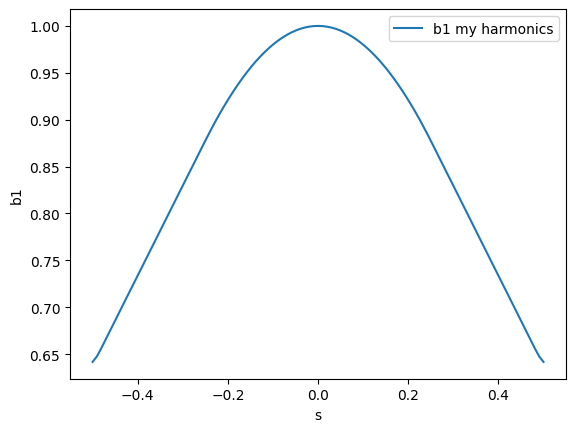

In [127]:
nk=4
nl=nk//2+1
dk = dkongrid(Byibx_rts=cilByiBx, rr=r_1d, nk=nk, s_index=s_1d.size // 2)
dkl = dklfitraw_nodiv_cheb(dkofrarray=dk, rr=r_1d, nk=nk, nl=nl)
#print(dkl)
an, bn = bnianHAopt(dkl, nl, nk).imag, bnianHAopt(dkl, nl, nk).real
print("an at s=",s_1d[s_1d.size // 2],": ",an)
print("bn:", bn)
rr = np.linspace(rmin, rmax, nr)
sHA, aHAofs, bHAofs = LH_s_nodiv_cheb(fieldyix=ByiBx_rts, ss=s_1d, korder=nk)

sc, aHAc, bHAc =LH_s_nodiv_cheb(fieldyix=cilByiBx, ss=s_1d, korder=nk)
plt.plot(sHA, bHAofs[:, 0], label="b1 my harmonics")
#plt.plot(svals, bnofs[:, 0], label="b1 from bpmeth")
plt.legend()
plt.xlabel("s")
plt.ylabel("b1")
# plt.ylim((2.2499, 2.25))
# plt.xlim((-0.01, 0.01))
plt.show()

In [128]:
import timeit
mytime = timeit.timeit(lambda: LH_s_nodiv_cheb(fieldyix=ByiBx_rts, ss=s_1d, korder=nk), number=100)
print(f"Time for 100 runs of LH_s_nodiv_cheb: {mytime:.4f} seconds")

Time for 100 runs of LH_s_nodiv_cheb: 18.7386 seconds


$$ \bar{b_1}(\bar{s})= b_1(s^*) + b_2(s^*)(\sqrt{\rho^2-2\rho\sin\theta_E\bar{s}+\bar{s}^2}-\rho) $$

In [129]:
# Build interpolants on the curved grid to be able to evaluate at s* points
cs_b1 = CubicSpline(sHA, bHAofs[:, 0])
cs_b2 = CubicSpline(sHA, bHAofs[:, 1])
theta_E=0.
sbarmax=0.2
s_bar_arr = np.linspace(-sbarmax, sbarmax, 103) #s_bar points in straight frame
# Compute s* for each s_bar point
s_star = rho * (theta_E - np.arctan(np.tan(theta_E) - s_bar_arr / (rho * np.cos(theta_E))))

# Intermediate quantity (appears in both terms)
Delta = np.sqrt(rho**2 - 2*rho*np.sin(theta_E)*s_bar_arr + s_bar_arr**2) - rho

# Evaluate bar_b1
b1_star = cs_b1(s_star)
b2_star = cs_b2(s_star)

b1_bar = b1_star + b2_star * Delta

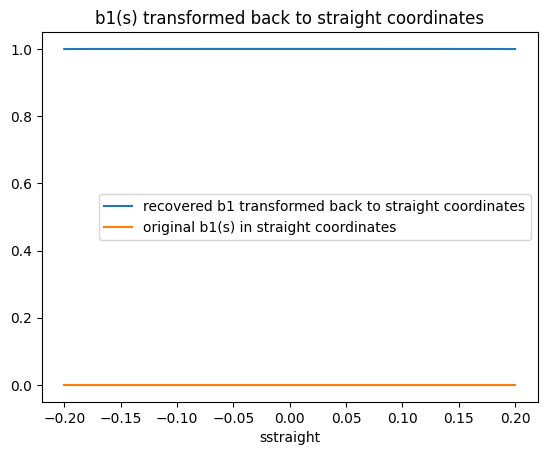

In [130]:
plt.plot(s_bar_arr, b1_bar, label='recovered b1 transformed back to straight coordinates')
plt.xlabel('sstraight')
plt.title('b1(s) transformed back to straight coordinates')
plt.plot(s_bar_arr, np.ones_like(s_bar_arr)*b_coeffs[0], label='original b1(s) in straight coordinates')
plt.legend()
plt.show()

$$
\bar{b_2}(\bar{s})=b_1'(s^*)\rho \frac{\rho\sin\theta_E-\bar{s}}{\rho^2-2\rho\sin\theta_E\bar{s}+\bar{s}^2} 
+b_2'(s^*)\rho\frac{\rho \sin\theta_E-\bar{s}}{\rho^2-2\rho\sin\theta_E\bar{s}+\bar{s}^2}(\sqrt{\rho^2-2\rho\sin\theta_E\bar{s}+\bar{s}^2}-\rho)+b_2(s^*) \frac{1 }{\sqrt{\rho^2-2\rho\sin\theta_E\bar{s}+\bar{s}^2}}$$

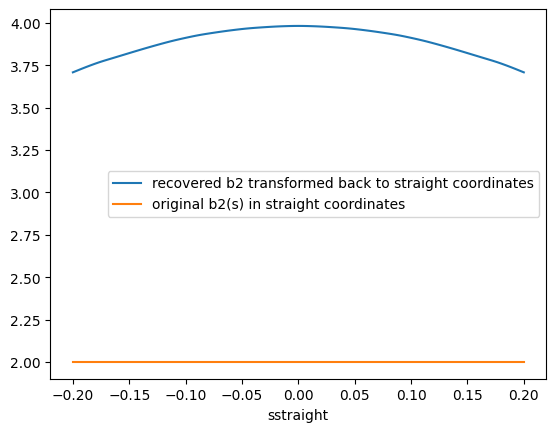

In [131]:
cs_b1_prime = cs_b1.derivative()
cs_b2_prime = cs_b2.derivative()
b1p_star = cs_b1_prime(s_star)
b2p_star = cs_b2_prime(s_star)
# Reusable intermediate quantities (already computed for b1_bar)
R = np.sqrt(rho**2 - 2*rho*np.sin(theta_E)*s_bar_arr + s_bar_arr**2)  # = rho + Delta
A = rho * (rho*np.sin(theta_E) - s_bar_arr) / R**2   # common angular factor
b2_bar = (b1p_star* A + b2p_star*A*Delta + b2_star/ R)
plt.plot(s_bar_arr, b2_bar, label='recovered b2 transformed back to straight coordinates')
plt.plot(s_bar_arr, b_coeffs[1]*np.ones_like(s_bar_arr), label='original b2(s) in straight coordinates')
plt.xlabel('sstraight')
plt.legend()
plt.show()